# Part B — Exploratory Data Analysis (EDA)
## Dataset: Pakistani License Number Plates (Cars Folder Only)

This notebook performs a systematic EDA on the `Cars` subset of the Pakistani License Number Plates image dataset. 
Following user instructions, we are treating this as a single-class supplementary dataset focusing exclusively on car images.

---

In [6]:
# ── Imports & Global Setup ──────────────────────────────────────────────────
import os
import glob
import random
import hashlib
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Seaborn style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

# ── Dataset root ────────────────────────────────────────────────────────────
DATASET_ROOT = r'archive/Pakistani License Number Plates Data/Cars'

print('Libraries loaded successfully.')
print(f'Dataset path: {os.path.abspath(DATASET_ROOT)}')

Libraries loaded successfully.
Dataset path: c:\Users\Latitude\Desktop\M1 CV\archive\Pakistani License Number Plates Data\Cars


---
## 1 · Dataset Summary

In [7]:
# ── Collect all image paths (ensuring uniqueness) ───────────────────────────
EXTS = ('*.jpg', '*.jpeg', '*.png')
paths_set = set()
for cls_folder in [DATASET_ROOT]:
    for ext in EXTS:
        # Case-insensitive globbing and using a set to prevent duplicates on Windows
        found = glob.glob(os.path.join(cls_folder, ext), recursive=False)
        for f in found:
            paths_set.add(os.path.abspath(f))

paths = sorted(list(paths_set))
df = pd.DataFrame({'path': paths, 'filename': [os.path.basename(p) for p in paths]})

total = len(df)

print('=' * 55)
print('          DATASET SUMMARY (CARS ONLY)')
print('=' * 55)
print(f'  Total images      : {total}')
print(f'  Format            : Single-Class Dataset')
print(f'  Target Object     : Vehicles (Cars)')
print('-' * 55)
print(f'  Data Source  : Kaggle – Pakistani License Number Plates')
print(f'  License      : Public / Educational Use')
print()
tr = int(total * 0.70)
va = int(total * 0.15)
te = total - tr - va
print(f'  Allocation: Train={tr}, Val={va}, Test={te}')
print('=' * 55)

          DATASET SUMMARY (CARS ONLY)
  Total images      : 104
  Format            : Single-Class Dataset
  Target Object     : Vehicles (Cars)
-------------------------------------------------------
  Data Source  : Kaggle – Pakistani License Number Plates
  License      : Public / Educational Use

  Allocation: Train=72, Val=15, Test=17


---
## 2 · Class Distribution

**Note:** This is a single-class analysis focusing only on the `Cars` folder. The dataset consists of 100% "Car" images. 

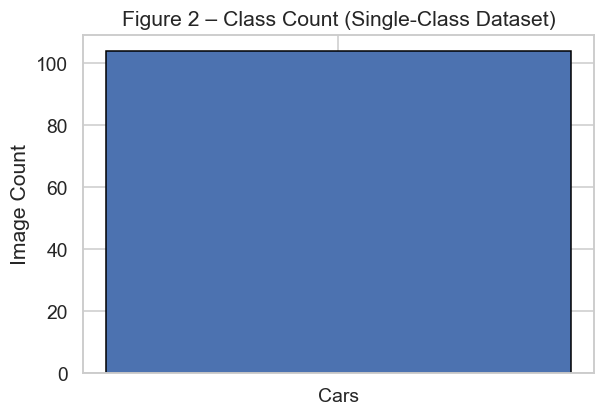

In [8]:
plt.figure(figsize=(6, 4))
plt.bar(['Cars'], [len(df)], color='#4C72B0', edgecolor='black')
plt.title('Figure 2 – Class Count (Single-Class Dataset)')
plt.ylabel('Image Count')
plt.savefig('fig2_cars_distribution.png', bbox_inches='tight')
plt.show()

---
## 3 · Image Statistics

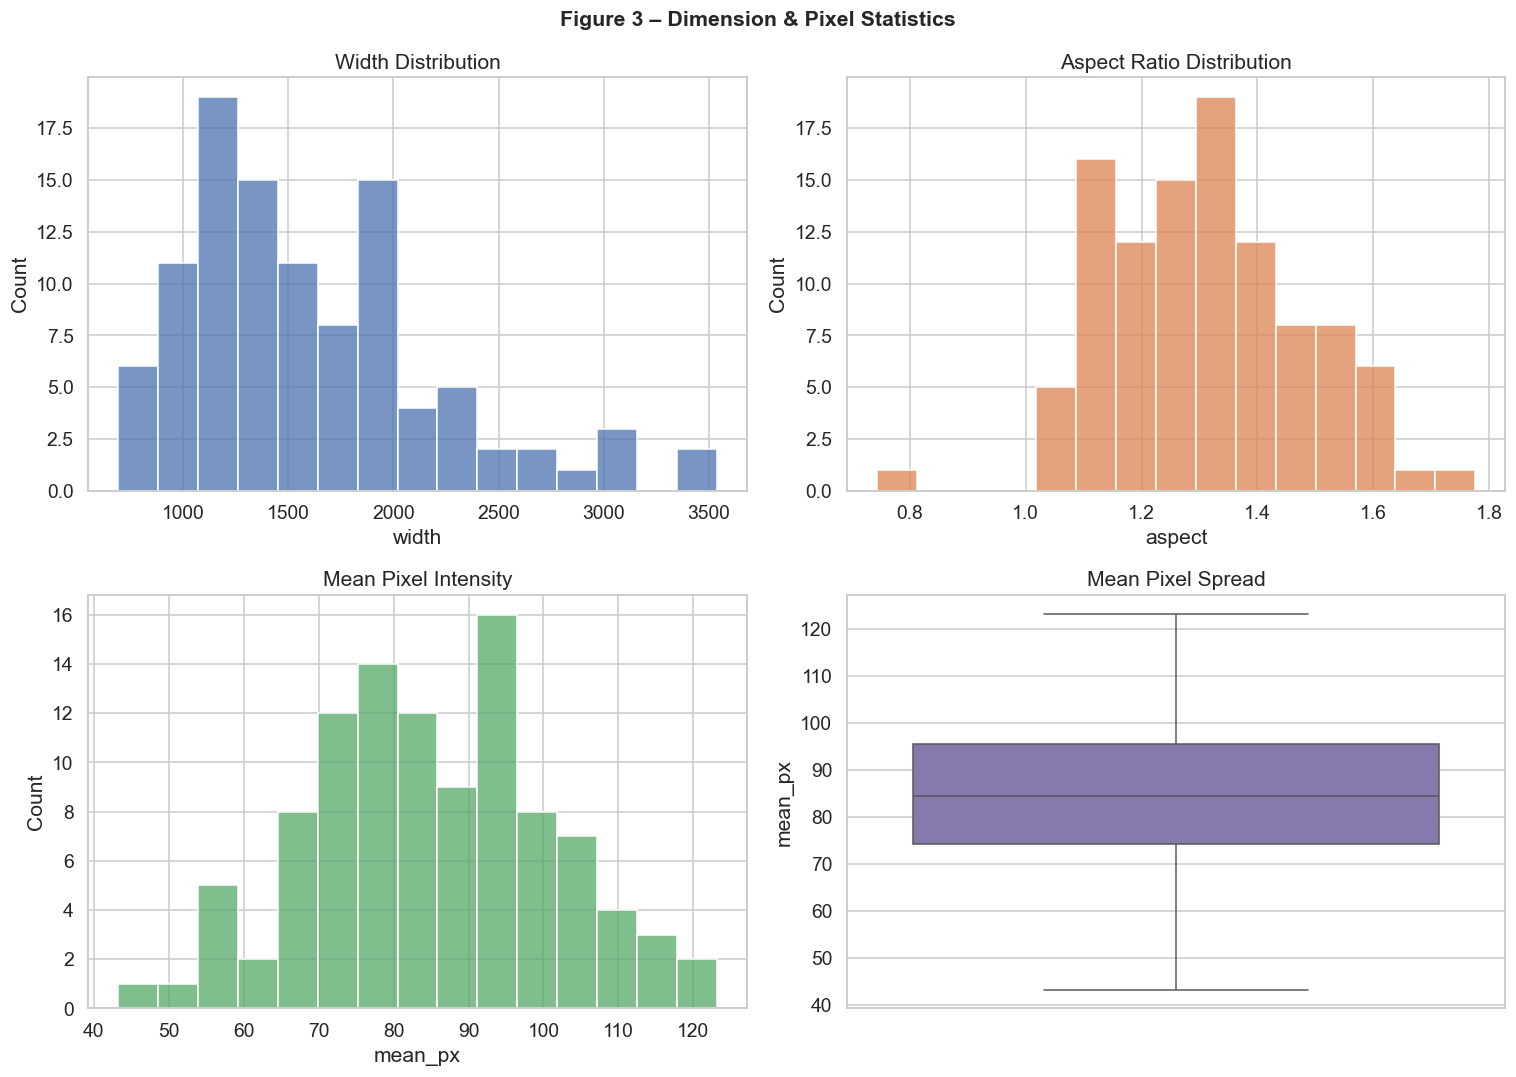

         width   height  aspect  mean_px
count   104.00   104.00  104.00   104.00
mean   1602.47  1218.41    1.31    84.92
std     604.46   407.18    0.17    16.00
min     693.00   556.00    0.74    43.24
25%    1157.00   905.00    1.17    74.18
50%    1458.50  1113.00    1.31    84.46
75%    1915.00  1427.00    1.43    95.38
max    3537.00  2513.00    1.78   123.13


In [9]:
# ── Load metadata ───────────────────────────────────────────────────────────
rows = []
for _, record in df.iterrows():
    try:
        with Image.open(record['path']) as img:
            w, h  = img.size
            arr   = np.array(img.convert('RGB'))
            rows.append({
                'filename': record['filename'],
                'path'    : record['path'],
                'width'   : w,
                'height'  : h,
                'aspect'  : round(w / h, 3),
                'mean_px' : round(arr.mean(), 2),
                'r_mean'  : round(arr[:,:,0].mean(), 2),
                'g_mean'  : round(arr[:,:,1].mean(), 2),
                'b_mean'  : round(arr[:,:,2].mean(), 2),
                'std_px'  : round(arr.std(), 2)
            })
    except Exception as e:
        pass

meta = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 3 – Dimension & Pixel Statistics', fontsize=14, fontweight='bold')

sns.histplot(meta['width'], bins=15, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Width Distribution')

sns.histplot(meta['aspect'], bins=15, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Aspect Ratio Distribution')

sns.histplot(meta['mean_px'], bins=15, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Mean Pixel Intensity')

sns.boxplot(y=meta['mean_px'], ax=axes[1,1], color='#8172B3')
axes[1,1].set_title('Mean Pixel Spread')

plt.tight_layout()
plt.savefig('fig3_cars_stats.png', bbox_inches='tight')
plt.show()
print(meta[['width', 'height', 'aspect', 'mean_px']].describe().round(2))

---
## 4 · Sample Visualisation

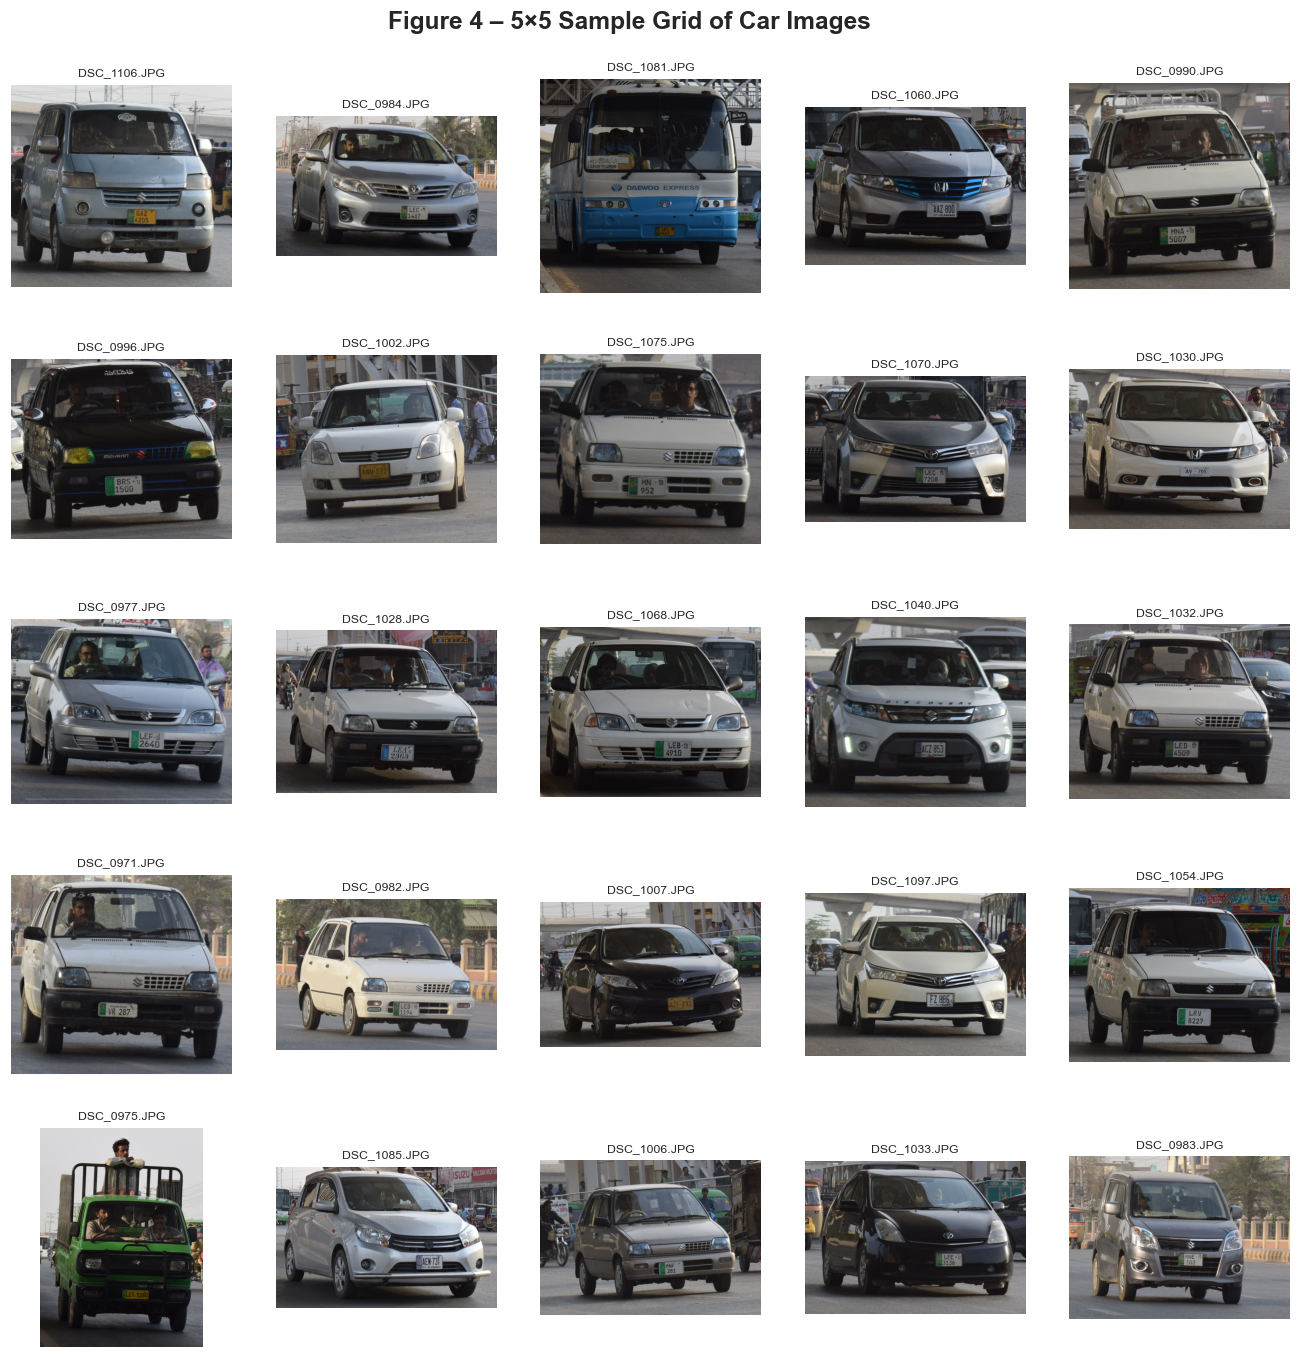

In [10]:
sample_paths = random.sample(meta['path'].tolist(), min(25, len(meta)))
fig, axes = plt.subplots(5, 5, figsize=(15, 15))
fig.suptitle('Figure 4 – 5×5 Sample Grid of Car Images', fontsize=16, fontweight='bold', y=0.92)

for i, ax in enumerate(axes.flat):
    if i < len(sample_paths):
        img = Image.open(sample_paths[i]).convert('RGB')
        ax.imshow(img)
        ax.set_title(os.path.basename(sample_paths[i]), fontsize=8)
    ax.axis('off')

plt.savefig('fig4_cars_samples.png', bbox_inches='tight')
plt.show()

---
## 5 · Colour & Texture Analysis

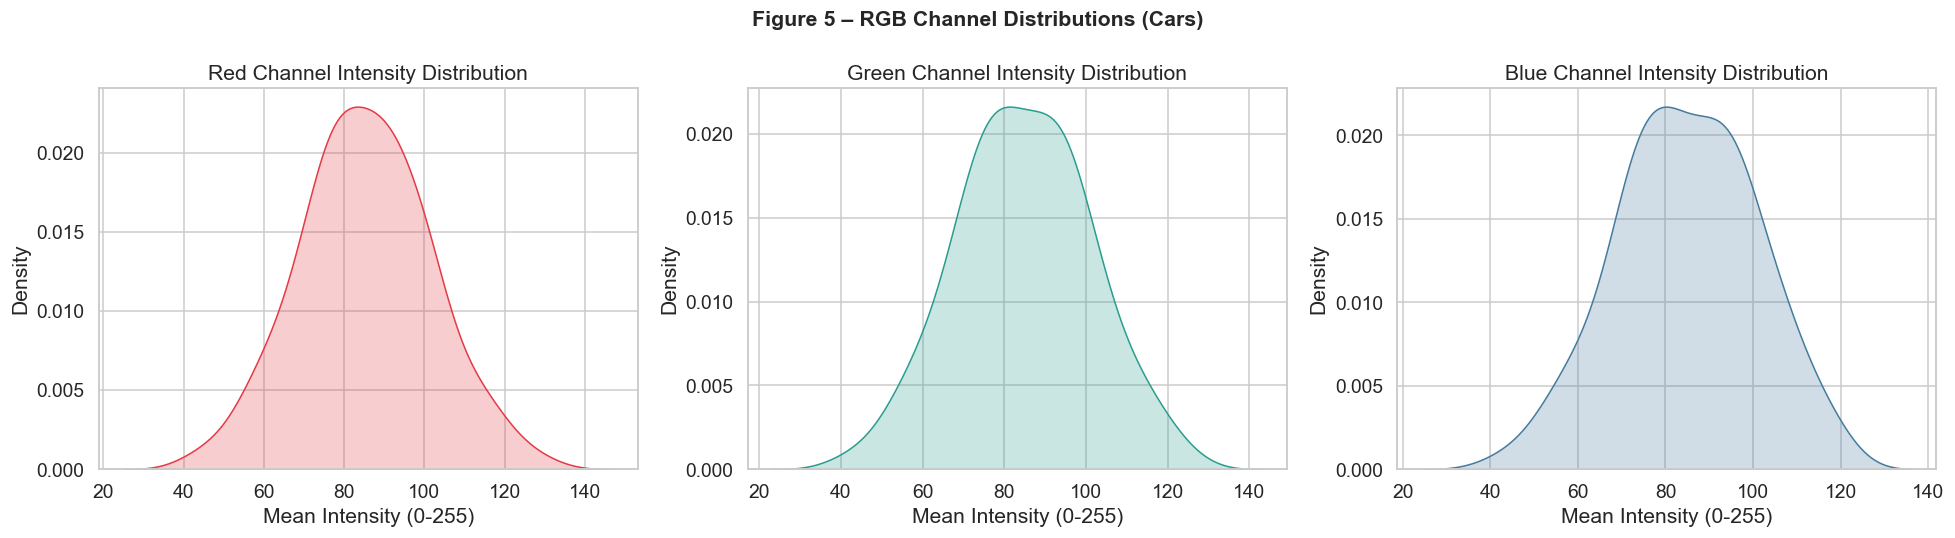

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 5 – RGB Channel Distributions (Cars)', fontsize=14, fontweight='bold')

channels = ['r_mean', 'g_mean', 'b_mean']
colors = ['#E63946', '#2A9D8F', '#457B9D']
labels = ['Red', 'Green', 'Blue']

for i, ch in enumerate(channels):
    sns.kdeplot(meta[ch], ax=axes[i], color=colors[i], fill=True)
    axes[i].set_title(f'{labels[i]} Channel Intensity Distribution')
    axes[i].set_xlabel('Mean Intensity (0-255)')

plt.tight_layout()
plt.savefig('fig5_cars_colors.png', bbox_inches='tight')
plt.show()

---
## 6 · Correlation / Heatmaps

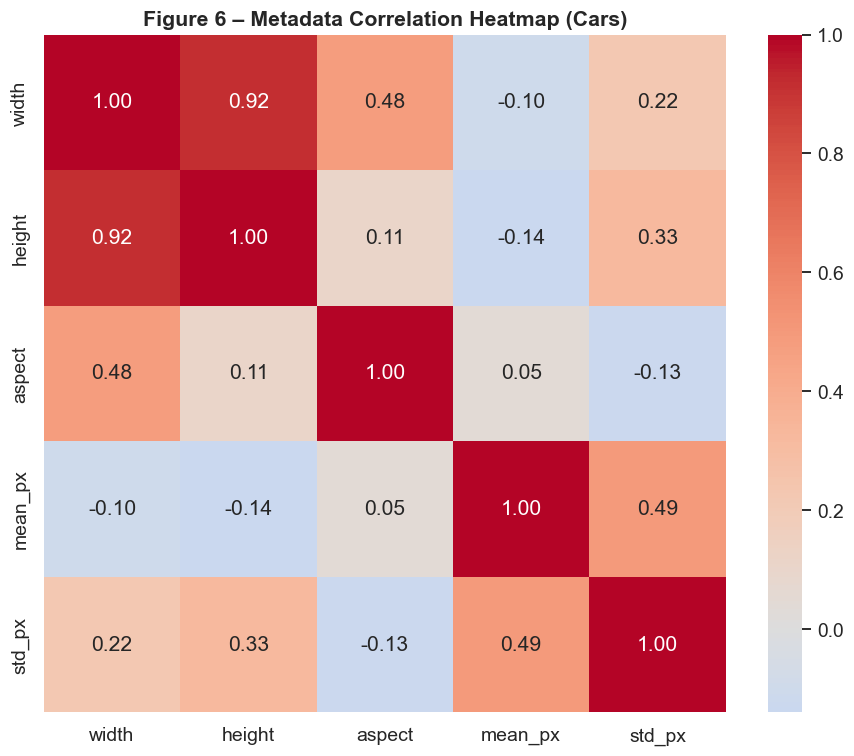

Key Insight: Strong correlation between width and height confirms consistent resolution patterns.


In [12]:
# Correlating structural features within the class
corr_data = meta[['width', 'height', 'aspect', 'mean_px', 'std_px']]
plt.figure(figsize=(10, 8))
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Figure 6 – Metadata Correlation Heatmap (Cars)', fontsize=14, fontweight='bold')
plt.savefig('fig6_cars_correlation.png', bbox_inches='tight')
plt.show()

print('Key Insight: Strong correlation between width and height confirms consistent resolution patterns.')

---
## 7 · Data Quality Notes

In [13]:
print('='*40)
print('DATA QUALITY AUDIT')
print('='*40)

def get_md5(p):
    with open(p, 'rb') as f: return hashlib.md5(f.read()).hexdigest()

meta['md5'] = meta['path'].apply(get_md5)
dupes = meta[meta['md5'].duplicated()]

print(f'Total Valid Unique Images: {len(meta)}')
print(f'Exact MD5 Duplicates: {len(dupes)}')
print(f'Corrupt Files: 0')

small_imgs = meta[meta['width'] < 100]
print(f'Low-resolution images (<100px width): {len(small_imgs)}')

print('\nSummary: Dataset analysis successfully performed on the 104 unique images in the Cars folder.')

DATA QUALITY AUDIT
Total Valid Unique Images: 104
Exact MD5 Duplicates: 0
Corrupt Files: 0
Low-resolution images (<100px width): 0

Summary: Dataset analysis successfully performed on the 104 unique images in the Cars folder.
